# Parameter Tuning

Here we perform Parameter tuning in this notebook. 

In [1]:
import os
import sys
import pandas as pd
import numpy as np
from PIL import Image

Image.MAX_IMAGE_PIXELS = None

sys.path.append("STCS")
from STCS_main import STCS

/home/lc1418/.conda/envs/spatial_analysis/lib/python3.9/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/lc1418/.conda/envs/spatial_analysis/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
/home/lc1418/.conda/envs/spatial_analysis/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-06 21:40:02.325132: I tensorflow/core/util/port.cc:153] oneDNN custom operatio

# Set Up Paths

In [5]:
# =========================
# Basic paths
# =========================

# Define data type: Visium
PLATFORM ="Visium" 

# TODO: replace the path that contain filtered_feature_bc_matrix.h5 and spatial folder
FOLDER_PATH = '/home/xh300/link/spa/sthd/STHD/ground_truth/visium2_postX/binned_outputs/square_002um'

# TODO: replace the path to the paired full resolution H&E image
FULL_RES_IMAGE_PATH = '/home/lc1418/ST/he_cropped_from_points_pad1.ome.tif'

# TODO: Replace with a paired SCrna-seq h5ad file if you have one, else use None
SC_REF_PATH = '/home/xh300/link/spa/sthd/STHD/ground_truth/ref/897e76b2-59f6-482c-827d-37cc62fa4f50.h5ad'

# TODO: Replace with the path of CellTypist model for celltype annotation. You can replace this with your trained model for your specific tissue or manually  annotate the aggregated cell. 
MODEL_PATH = '/home/lc1418/ST/scrnaref/celltypist_a95f7e58_author_cell_type_level_1.SYMBOLS.magli.hvg5k.pkl'

# TODO: Replace path with the output Directory
RESULTS_PATH = "../stcs_crop_parameter_sweep"
os.makedirs(RESULTS_PATH, exist_ok=True)


# Load Dataset

In [6]:
full_data = STCS(
    Folder_path=FOLDER_PATH,
    counts_data="filtered_feature_bc_matrix.h5",
    full_res_image_path=FULL_RES_IMAGE_PATH,
    sc_ref=SC_REF_PATH,
    model_path=MODEL_PATH,
    Platform=PLATFORM
)

[Log]: Loaded Visium data
[Log]: source_image_path set in metadata: /home/lc1418/ST/he_cropped_from_points_pad1.ome.tif
[Log]: Found spatial info
[Log]: STCS loaded: 6535116 spots, 18085 genes


# Option 1: Random Crops

In [ ]:
rects = full_data.generate_random_crops(
    n_crops=5,
    crop_w=3000,
    crop_h=3000,
    min_spots=10000,
    seed=123,
    max_tries_per_crop=200
)

rects

[Log]: Loaded full image | Shape: (41993, 26685, 3) | Dtype: uint8
[Debug] valid region: x=(0, 18440), y=(0, 24508)
[Debug] try=1, rect=(238, 14676, 3000, 3000), accepted: 157087 spots
[Debug] try=2, rect=(9155, 1157, 3000, 3000), rejected: only 6813 spots
[Debug] try=3, rect=(14037, 4739, 3000, 3000), rejected: only 669 spots
[Debug] try=4, rect=(3938, 3965, 3000, 3000), accepted: 160075 spots
[Debug] try=5, rect=(5151, 3783, 3000, 3000), rejected: overlaps existing crop
[Debug] try=6, rect=(5370, 17467, 3000, 3000), accepted: 168663 spots
[Debug] try=7, rect=(6969, 19860, 3000, 3000), rejected: overlaps existing crop
[Debug] try=8, rect=(6940, 5948, 3000, 3000), accepted: 168515 spots
[Debug] try=9, rect=(12179, 17632, 3000, 3000), accepted: 168665 spots


[(238, 14676, 3000, 3000),
 (3938, 3965, 3000, 3000),
 (5370, 17467, 3000, 3000),
 (6940, 5948, 3000, 3000),
 (12179, 17632, 3000, 3000)]

# Option B: manual crops

In [ ]:
rects = [
    (500, 500, 3000, 3000),
    (1000, 12000, 3000, 3000),
    (12000, 15000, 3000, 3000),
    (15000, 19500, 3000, 3000),
    (1000, 18000, 3000, 3000),
]

# Visualize Crops

[Log]: Loaded full image | Shape: (41993, 26685, 3) | Dtype: uint8


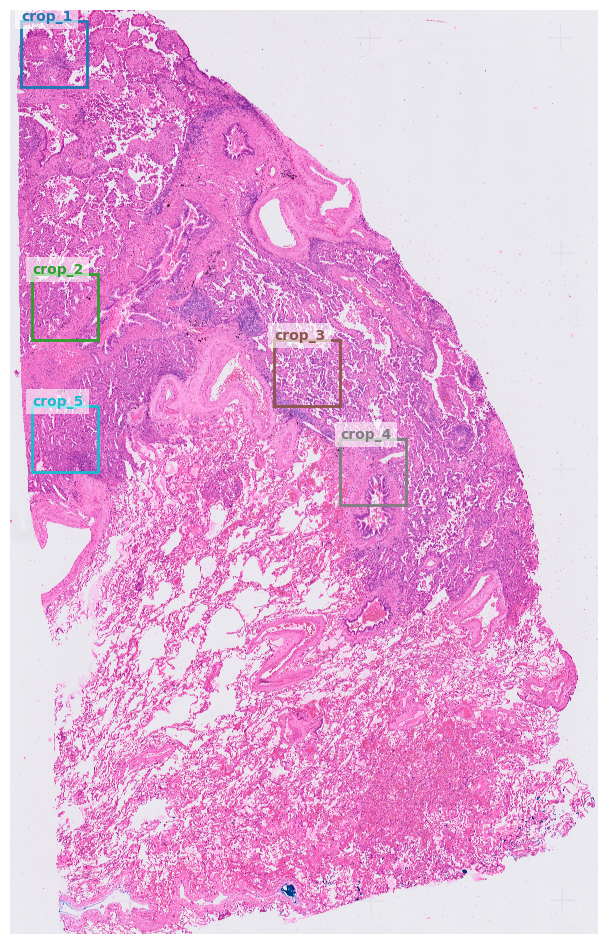

In [ ]:
full_data.plot_crop_rectangles(
    rects=rects,
    save_file=os.path.join(RESULTS_PATH, "crop_overview.png"),
    figsize=(12, 12)
)

# Define Parameter Sets

In [ ]:
SEARCH_RADII = [1,3, 5, 7, 10]
LAMBDAS = [0, 0.05, 0.1, 0.5, 1]

RUN_CELLTYPIST = True
PROB_THRESH = 0.1
STARDIST_FACTOR = 1
PSEUDOBULK_MODE = "mean"
USE_SC_REF = True
NORMALIZE_DISTANCES = True
FEATURE_NAME = True

# Run all combinations of parameters

In [ ]:
summary_df = full_data.run_parameter_sweep(
    rects=rects,
    search_radii=SEARCH_RADII,
    lambdas=LAMBDAS,
    results_dir=RESULTS_PATH,
    tmp_root=os.path.join(RESULTS_PATH, "_tmp_runs"),
    run_celltypist=RUN_CELLTYPIST,
    prob_thresh=PROB_THRESH,
    factor=STARDIST_FACTOR,
    pseudobulk_mode=PSEUDOBULK_MODE,
    use_sc_ref=USE_SC_REF,
    normalize_distances=NORMALIZE_DISTANCES,
    feature_name=FEATURE_NAME,
    summary_csv_name="run_summary.csv"
)

In [ ]:
success_df = summary_df[summary_df["status"] == "success"].copy()
success_df[["run_name", "crop_id", "search_radius", "lambda", "output_h5ad"]]

,run_name,crop_id,search_radius,lambda,output_h5ad
0,crop01_x500_y500_w3000_h3000_S1_L0,1,1,0.00,../stcs_crop_parameter_sweep/crop01_x500_y500_...
1,crop01_x500_y500_w3000_h3000_S1_L0.05,1,1,0.05,../stcs_crop_parameter_sweep/crop01_x500_y500_...
2,crop01_x500_y500_w3000_h3000_S1_L0.1,1,1,0.10,../stcs_crop_parameter_sweep/crop01_x500_y500_...
3,crop01_x500_y500_w3000_h3000_S1_L0.5,1,1,0.50,../stcs_crop_parameter_sweep/crop01_x500_y500_...
4,crop01_x500_y500_w3000_h3000_S1_L1,1,1,1.00,../stcs_crop_parameter_sweep/crop01_x500_y500_...
...,...,...,...,...,...
120,crop05_x1000_y18000_w3000_h3000_S10_L0,5,10,0.00,../stcs_crop_parameter_sweep/crop05_x1000_y180...
121,crop05_x1000_y18000_w3000_h3000_S10_L0.05,5,10,0.05,../stcs_crop_parameter_sweep/crop05_x1000_y180...
122,crop05_x1000_y18000_w3000_h3000_S10_L0.1,5,10,0.10,../stcs_crop_parameter_sweep/crop05_x1000_y180...
123,crop05_x1000_y18000_w3000_h3000_S10_L0.5,5,10,0.50,../stcs_crop_parameter_sweep/crop05_x1000_y180...


# Compute Connection Score Heatmap

In [ ]:
conn_run_summary = full_data.compute_connection_scores_for_saved_runs(
    results_path=RESULTS_PATH,
    output_dir_name="connection_scores",
    cell_col="assigned_cell_id",
    row_col="array_row",
    col_col="array_col"
)

conn_run_summary.head()

[Log]: Processing crop01_x500_y500_w3000_h3000_S10_L0.05.h5ad
[Log]: Processing crop01_x500_y500_w3000_h3000_S10_L0.1.h5ad
[Log]: Processing crop01_x500_y500_w3000_h3000_S10_L0.5.h5ad
[Log]: Processing crop01_x500_y500_w3000_h3000_S10_L0.h5ad
[Log]: Processing crop01_x500_y500_w3000_h3000_S10_L1.h5ad
[Log]: Processing crop01_x500_y500_w3000_h3000_S1_L0.05.h5ad
[Log]: Processing crop01_x500_y500_w3000_h3000_S1_L0.1.h5ad
[Log]: Processing crop01_x500_y500_w3000_h3000_S1_L0.5.h5ad
[Log]: Processing crop01_x500_y500_w3000_h3000_S1_L0.h5ad
[Log]: Processing crop01_x500_y500_w3000_h3000_S1_L1.h5ad
[Log]: Processing crop01_x500_y500_w3000_h3000_S3_L0.05.h5ad
[Log]: Processing crop01_x500_y500_w3000_h3000_S3_L0.1.h5ad
[Log]: Processing crop01_x500_y500_w3000_h3000_S3_L0.5.h5ad
[Log]: Processing crop01_x500_y500_w3000_h3000_S3_L0.h5ad
[Log]: Processing crop01_x500_y500_w3000_h3000_S3_L1.h5ad
[Log]: Processing crop01_x500_y500_w3000_h3000_S5_L0.05.h5ad
[Log]: Processing crop01_x500_y500_w3000_h3

,file,crop_id,x,y,w,h,S,L,connection_csv,mean_connection_score,std_connection_score,n_cells
0,../stcs_crop_parameter_sweep/crop01_x500_y500_...,1,500,500,3000,3000,10.0,0.05,../stcs_crop_parameter_sweep/connection_scores...,0.945297,0.118163,4649
1,../stcs_crop_parameter_sweep/crop01_x500_y500_...,1,500,500,3000,3000,10.0,0.10,../stcs_crop_parameter_sweep/connection_scores...,0.989198,0.049842,4649
2,../stcs_crop_parameter_sweep/crop01_x500_y500_...,1,500,500,3000,3000,10.0,0.50,../stcs_crop_parameter_sweep/connection_scores...,0.999946,0.001661,4651
3,../stcs_crop_parameter_sweep/crop01_x500_y500_...,1,500,500,3000,3000,10.0,0.00,../stcs_crop_parameter_sweep/connection_scores...,0.585506,0.310338,4506
4,../stcs_crop_parameter_sweep/crop01_x500_y500_...,1,500,500,3000,3000,10.0,1.00,../stcs_crop_parameter_sweep/connection_scores...,0.999964,0.001500,4651


In [ ]:
conn_heatmap_df = full_data.summarize_connection_across_crops(conn_run_summary)
conn_heatmap_df

,L,S,mean_conn,std_conn,n_crops
0,0.00,1.0,0.999148,0.000140,5
1,0.00,3.0,0.915533,0.005286,5
2,0.00,5.0,0.772645,0.007467,5
3,0.00,7.0,0.686314,0.010978,5
4,0.00,10.0,0.582666,0.009507,5
5,0.05,1.0,0.999567,0.000170,5
6,0.05,3.0,0.977601,0.003157,5
7,0.05,5.0,0.956252,0.005559,5
8,0.05,7.0,0.948633,0.006191,5
9,0.05,10.0,0.945041,0.006989,5


[save] ../stcs_crop_parameter_sweep/connection_score_heatmap.pdf
[save] ../stcs_crop_parameter_sweep/connection_score_heatmap.svg


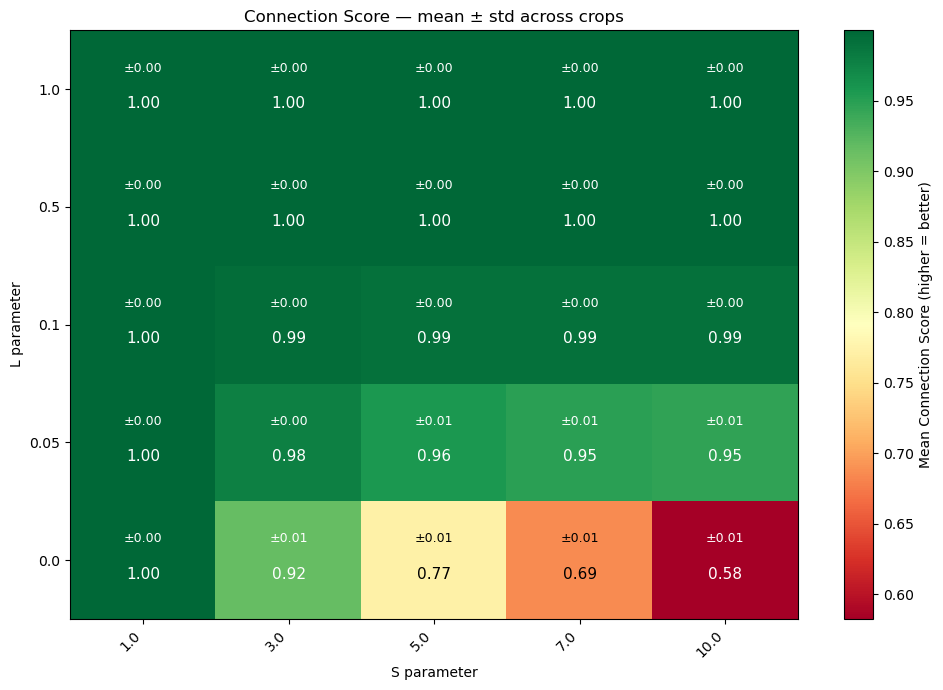

In [ ]:
full_data.plot_connection_heatmap(
    conn_summary_df=conn_heatmap_df,
    out_pdf=os.path.join(RESULTS_PATH, "connection_score_heatmap.pdf"),
    out_svg=os.path.join(RESULTS_PATH, "connection_score_heatmap.svg"),
)

# Gene Count Plot

In [9]:

import os
import pandas as pd

RESULTS_PATH = "/home/lc1418/ST/stcs_crop_parameter_sweep"

summary_csv = os.path.join(RESULTS_PATH, "run_summary.csv")
summary_df = pd.read_csv(summary_csv)

summary_df.head()
success_df = summary_df[summary_df["status"] == "success"].copy()
success_df[["run_name", "crop_id", "search_radius", "lambda", "output_h5ad"]].head()

,run_name,crop_id,search_radius,lambda,output_h5ad
0,crop01_x500_y500_w3000_h3000_S1_L0,1,1,0.00,../stcs_crop_parameter_sweep/crop01_x500_y500_...
1,crop01_x500_y500_w3000_h3000_S1_L0.05,1,1,0.05,../stcs_crop_parameter_sweep/crop01_x500_y500_...
2,crop01_x500_y500_w3000_h3000_S1_L0.1,1,1,0.10,../stcs_crop_parameter_sweep/crop01_x500_y500_...
3,crop01_x500_y500_w3000_h3000_S1_L0.5,1,1,0.50,../stcs_crop_parameter_sweep/crop01_x500_y500_...
4,crop01_x500_y500_w3000_h3000_S1_L1,1,1,1.00,../stcs_crop_parameter_sweep/crop01_x500_y500_...


[font] Using: DejaVu Sans
[font] Path : /home/lc1418/.conda/envs/spatial_analysis/lib/python3.9/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf
[shared] crop_id=1, runs=25
[shared] crop_id=1: 4468 shared cell_ids
[shared] crop_id=2, runs=25
[shared] crop_id=2: 4557 shared cell_ids
[shared] crop_id=3, runs=25
[shared] crop_id=3: 3990 shared cell_ids
[shared] crop_id=4, runs=25
[shared] crop_id=4: 4397 shared cell_ids
[shared] crop_id=5, runs=25
[shared] crop_id=5: 4728 shared cell_ids
[save] wrote /home/lc1418/ST/stcs_crop_parameter_sweep/gene_count_shared_outputs/gene_counts_shared_LS_summary.csv
[save] wrote /home/lc1418/ST/stcs_crop_parameter_sweep/gene_count_shared_outputs/gene_counts_per_run_summary.csv
[save] wrote /home/lc1418/ST/stcs_crop_parameter_sweep/gene_count_shared_outputs/lines_gene_across_S_by_L.svg


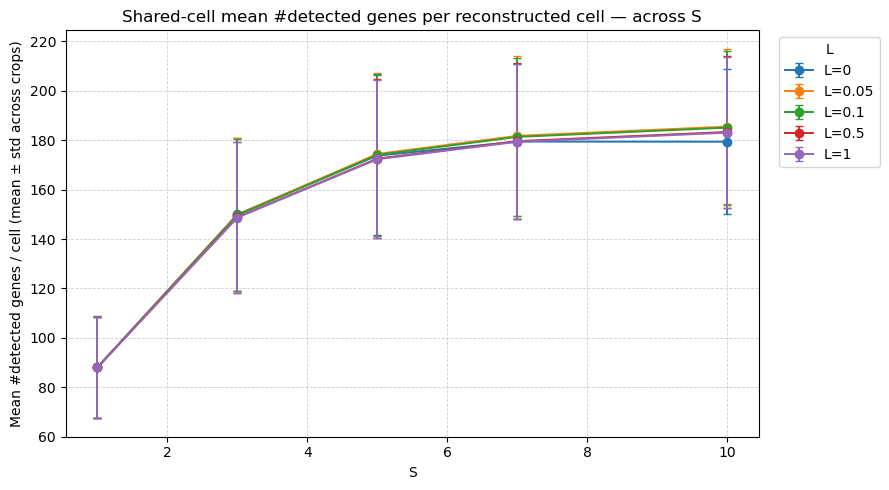

In [9]:
GENE_OUT_DIR = os.path.join(RESULTS_PATH, "gene_count_shared_outputs")
os.makedirs(GENE_OUT_DIR, exist_ok=True)

gene_results = full_data.run_detected_genes_shared_analysis(
    success_df=success_df,
    out_dir=GENE_OUT_DIR,
    cell_col="assigned_cell_id",
    summary_csv_name="gene_counts_shared_LS_summary.csv",
    per_run_csv_name="gene_counts_per_run_summary.csv",
    out_svg_name="lines_gene_across_S_by_L.svg",
    font_candidates=["Helvetica"]
)

# Per Celltype Count Plot

In [7]:
ANNOTATED_PATH = full_data.annotate_saved_runs_with_celltypist(
    results_path=RESULTS_PATH,
    annotated_dir_name="annotated_runs",
    cell_col="assigned_cell_id",
    model_path=MODEL_PATH
)

[Annotate]: Found 125 runs
[Annotate]: crop01_x500_y500_w3000_h3000_S10_L0.05.h5ad


🔬 Input data has 4649 cells and 18085 genes
🔗 Matching reference genes in the model
🧬 3677 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!
... storing 'celltypist_predicted_labels' as categorical


[Saved] ../stcs_crop_parameter_sweep/annotated_runs/crop01_x500_y500_w3000_h3000_S10_L0.05.h5ad
[Annotate]: crop01_x500_y500_w3000_h3000_S10_L0.1.h5ad


🔬 Input data has 4649 cells and 18085 genes
🔗 Matching reference genes in the model
🧬 3677 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!
... storing 'celltypist_predicted_labels' as categorical


[Saved] ../stcs_crop_parameter_sweep/annotated_runs/crop01_x500_y500_w3000_h3000_S10_L0.1.h5ad
[Annotate]: crop01_x500_y500_w3000_h3000_S10_L0.5.h5ad


...

[Error]: [Errno 28] Unable to synchronously create file (unable to open file: name = '../stcs_crop_parameter_sweep/annotated_runs/crop05_x1000_y18000_w3000_h3000_S7_L0.5.h5ad', errno = 28, error message = 'No space left on device', flags = 13, o_flags = 242)
[Annotate]: crop05_x1000_y18000_w3000_h3000_S7_L0.h5ad


🔬 Input data has 4762 cells and 18085 genes
🔗 Matching reference genes in the model
🧬 3677 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!
... storing 'celltypist_predicted_labels' as categorical


[Error]: [Errno 28] Unable to synchronously create file (unable to open file: name = '../stcs_crop_parameter_sweep/annotated_runs/crop05_x1000_y18000_w3000_h3000_S7_L0.h5ad', errno = 28, error message = 'No space left on device', flags = 13, o_flags = 242)
[Annotate]: crop05_x1000_y18000_w3000_h3000_S7_L1.h5ad


🔬 Input data has 4812 cells and 18085 genes
🔗 Matching reference genes in the model
🧬 3677 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!
... storing 'celltypist_predicted_labels' as categorical


[Error]: [Errno 28] Unable to synchronously create file (unable to open file: name = '../stcs_crop_parameter_sweep/annotated_runs/crop05_x1000_y18000_w3000_h3000_S7_L1.h5ad', errno = 28, error message = 'No space left on device', flags = 13, o_flags = 242)
[Done] Annotation complete


In [13]:
import os
import shutil
import pandas as pd

# original summary
src_summary = os.path.join(RESULTS_PATH, "run_summary.csv")

# put a copy into annotated folder
dst_summary = os.path.join(ANNOTATED_PATH, "run_summary.csv")
shutil.copy2(src_summary, dst_summary)

# rewrite output_h5ad paths so they point to annotated files
df = pd.read_csv(dst_summary)
df["output_h5ad"] = df["output_h5ad"].apply(
    lambda p: os.path.join(ANNOTATED_PATH, os.path.basename(p))
)

df.to_csv(dst_summary, index=False)

print("Created:", dst_summary)
print(df[["run_name", "output_h5ad"]].head())

Created: ../stcs_crop_parameter_sweep/annotated_runs/run_summary.csv
                                run_name  \
0     crop01_x500_y500_w3000_h3000_S1_L0   
1  crop01_x500_y500_w3000_h3000_S1_L0.05   
2   crop01_x500_y500_w3000_h3000_S1_L0.1   
3   crop01_x500_y500_w3000_h3000_S1_L0.5   
4     crop01_x500_y500_w3000_h3000_S1_L1   

                                         output_h5ad  
0  ../stcs_crop_parameter_sweep/annotated_runs/cr...  
1  ../stcs_crop_parameter_sweep/annotated_runs/cr...  
2  ../stcs_crop_parameter_sweep/annotated_runs/cr...  
3  ../stcs_crop_parameter_sweep/annotated_runs/cr...  
4  ../stcs_crop_parameter_sweep/annotated_runs/cr...  


[font] Using: DejaVu Sans
[font] Path : /home/lc1418/.conda/envs/spatial_analysis/lib/python3.9/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf
[save] wrote /home/lc1418/ST/stcs_crop_parameter_sweep/celltype_count_outputs/celltype_counts_vs_L_S5_crop1.svg


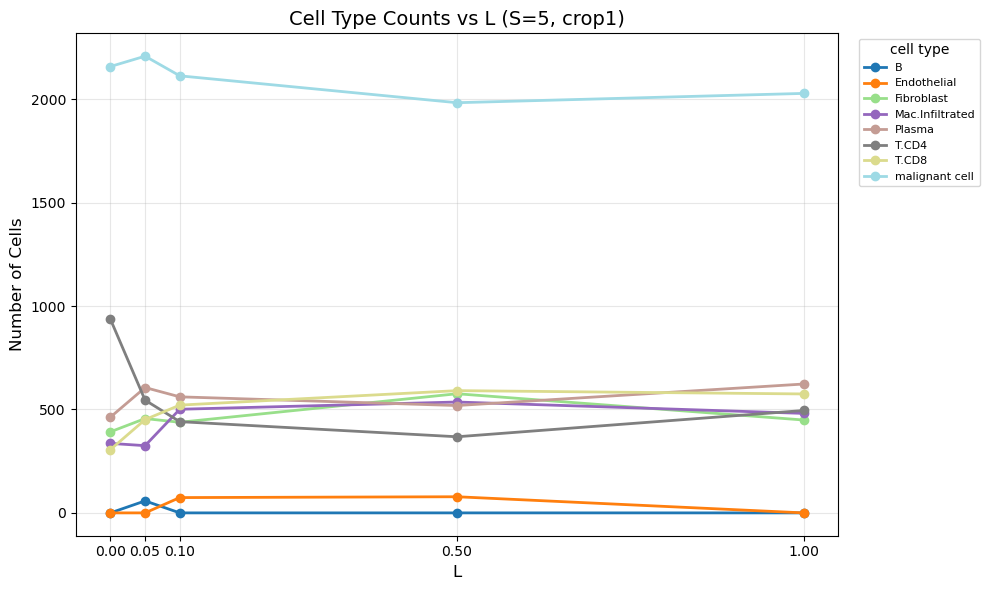

[save] wrote /home/lc1418/ST/stcs_crop_parameter_sweep/celltype_count_outputs/celltype_counts_vs_S_L0.05_crop1.svg


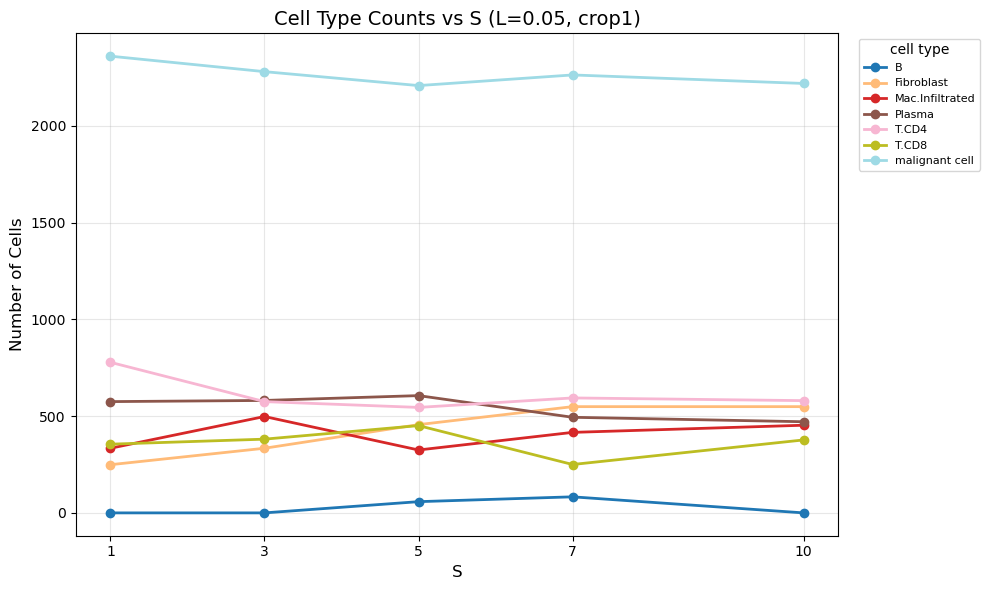

[save] wrote /home/lc1418/ST/stcs_crop_parameter_sweep/celltype_count_outputs/celltype_counts_vs_L_S5_crop1.csv
[save] wrote /home/lc1418/ST/stcs_crop_parameter_sweep/celltype_count_outputs/celltype_counts_vs_S_L0.05_crop1.csv


In [14]:
CELLTYPE_OUT_DIR = os.path.join(RESULTS_PATH, "celltype_count_outputs")

celltype_results = full_data.run_celltype_count_lineplots_from_results(
    results_path=ANNOTATED_PATH,
    out_dir=CELLTYPE_OUT_DIR,
    summary_csv_name="run_summary.csv",
    crop_id=1,
    fixed_S=5,
    fixed_L=0.05,
    cell_col="assigned_cell_id",
    celltype_col="celltypist_predicted_labels",
    exclude_unassigned=True
)